# Exploratory data analysis

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn


##### Using historical wildfire data, the model aims to predict risk bands that can help alert responsible agencies to promptly respond to areas that may be at high risk. 

In [3]:
dataset=pd.read_csv('https://cwfis.cfs.nrcan.gc.ca/downloads/fwi_obs/cwfis_fwi2020s.csv')
dataset.columns

Index(['aes', 'wmo', 'rep_date', 'temp', 'td', 'rh', 'ws', 'wg', 'wdir',
       'pres', 'vis', 'precip', 'rndays', 'sog', 'ffmc', 'dmc', 'dc', 'bui',
       'isi', 'fwi', 'dsr', 'opts', 'calcstatus'],
      dtype='object')

'aes' - station identifier number
'wmo' World meteo org station id number assigned by WFIS. 
'rep_date' - Report date
'temp' - temperature
'td' - noon dewpoint temperature 
'rh' - relative humidity
'ws' - wind speed
'wg' - wind gust speed km/h
'wdir' - wind direction
'pres' - pressure
'vis' - visibility in kms
'precip' -  24hr precipitation in mm
'rndays' - rainy days
'sog' - Snow depth on ground in cm
'ffmc' - final fuel moisture code, assesses the relative ease of ignition
'dmc' - diff moisture code, used in assessing the potential of lightning caused ignition
'dc' - drought code, seasonal drought effects on forest feuls 
'bui' - buildup index, indicates the total fuel availible for consumption. Higher fuel consumption could indicate higher fire intensity
'isi' - initial spread index, expected rate of fire spread. Based on wind speed and ffmc
'fwi' - fire weather index, numeric rating of fire intensity associated with a fire spreading through a forest. used to indicate the fire danger through forested areas. 
'dsr' - daily severity rating, numeric rating of difficulty of controlling fires
'opts' - Options used in the CFFWIS calculations by location.
'calcstatus' - calculation status, -3: Station in winter mode. Snow may cover ground for atleast 7 days. 0: Short term shutdown, cold temp or snow may be present indicating no fire danger, 1: Fuel moisture codes are calculated normally. 

In [4]:
dataset

,aes,wmo,rep_date,temp,td,rh,ws,wg,wdir,pres,...,sog,ffmc,dmc,dc,bui,isi,fwi,dsr,opts,calcstatus
0,1012475,71031,2020-01-01 12:00:00,9.5,8.6,94.0,8.6,23.2,261,1007.7,...,0.0,8.9,0.1,85.6,0.1,0.0,0.0,0.0,IDW=R:M=1:,1
1,1012710,71798,2020-01-01 12:00:00,10.2,6.2,76.0,35.8,45.7,252,1007.8,...,0.0,35.6,0.3,1.5,0.4,0.1,0.0,0.0,M=1:,1
2,1014820,71774,2020-01-01 12:00:00,9.4,5.5,76.9,23.4,NaN,255,1006.6,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IDW=RH:WSD:R:M=1:,-3
3,1015630,71927,2020-01-01 12:00:00,11.6,4.4,61.0,12.0,24.1,257,1007.0,...,0.0,36.9,0.5,1.8,0.6,0.0,0.0,0.0,M=1:,1
4,1016640,71778,2020-01-01 12:00:00,9.2,6.9,85.0,45.0,54.0,259,1008.8,...,0.0,28.8,0.2,1.4,0.2,0.0,0.0,0.0,IDW=R:M=1:,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3162100,8502592,71339,2025-01-21 12:00:00,-13.6,-18.9,65.0,18.4,NaN,280,1004.6,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M=1:,-3
3162101,8502799,71665,2025-01-21 12:00:00,-23.0,-28.9,59.0,25.8,NaN,252,996.5,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IDW=WSD:R:M=1:,-3
3162102,8502801,71902,2025-01-21 12:00:00,-23.1,-28.8,61.0,25.8,NaN,252,997.0,...,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IDW=WSD:R:M=1:,-3
3162103,8504175,71825,2025-01-21 12:00:00,-30.9,-36.5,59.0,20.5,NaN,271,1015.4,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M=1:,-3


### Exploring the dataset to find out values that make up each column

In [5]:
dataset.describe()

,wmo,temp,td,rh,ws,wg,wdir,pres,vis,precip,rndays,sog,ffmc,dmc,dc,bui,isi,fwi,dsr,calcstatus
count,3.162105e+06,3.162105e+06,3.160360e+06,3.161450e+06,3.162102e+06,2.488645e+06,3.162105e+06,3.162089e+06,3.161132e+06,3.162025e+06,3.162105e+06,3.161704e+06,2.175922e+06,2.175875e+06,2.175838e+06,2.090537e+06,2.088235e+06,2.087874e+06,2.087874e+06,3.162105e+06
mean,2.342355e+05,1.022938e+01,1.758527e+00,6.105013e+01,1.414116e+01,1.813161e+01,1.951835e+02,8.765331e+03,1.955511e+01,2.065048e+00,3.351370e+00,2.773125e+00,7.402552e+01,3.507197e+01,2.925922e+02,5.030362e+01,5.604154e+00,1.258605e+01,5.098573e+00,-2.807699e-01
std,2.862881e+05,1.366870e+01,1.161199e+01,2.142467e+01,9.664428e+00,1.378539e+01,1.025152e+02,8.802000e+05,8.875788e+00,4.029062e+01,8.949840e+00,1.091236e+01,2.123082e+01,5.856357e+01,2.713290e+02,6.934977e+01,5.149621e+01,1.709350e+01,2.035717e+01,1.846069e+00
min,2.000000e+03,-5.360000e+01,-6.000000e+01,-7.740000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-9.860000e+01,0.000000e+00,0.000000e+00,-9.900000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-3.000000e+00
25%,7.128500e+04,1.900000e+00,-4.900000e+00,4.500000e+01,7.400000e+00,8.300000e+00,1.190000e+02,1.010000e+03,1.610000e+01,0.000000e+00,0.000000e+00,0.000000e+00,6.550000e+01,7.100000e+00,8.900000e+01,1.180000e+01,1.000000e+00,7.000000e-01,0.000000e+00,-3.000000e+00
50%,7.182100e+04,1.200000e+01,3.000000e+00,6.190000e+01,1.230000e+01,1.440000e+01,2.100000e+02,1.015310e+03,1.610000e+01,0.000000e+00,1.000000e+00,0.000000e+00,8.310000e+01,1.820000e+01,2.280000e+02,2.890000e+01,3.300000e+00,6.700000e+00,8.000000e-01,1.000000e+00
75%,7.000390e+05,2.050000e+01,1.000000e+01,7.800000e+01,1.850000e+01,2.520000e+01,2.790000e+02,1.020600e+03,2.280000e+01,1.000000e+00,4.000000e+00,0.000000e+00,8.850000e+01,4.180000e+01,4.210000e+02,6.360000e+01,7.100000e+00,1.770000e+01,4.400000e+00,1.000000e+00
max,7.225540e+05,5.930000e+01,4.750000e+01,1.340000e+02,1.963000e+02,1.963000e+02,3.600000e+02,1.000000e+08,1.000000e+02,3.878400e+04,6.660000e+02,2.430000e+02,1.010000e+02,1.577100e+03,4.015800e+03,1.573400e+03,6.321740e+04,1.957300e+03,1.822990e+04,1.000000e+00


##### As mentioned in the column description panel:
#####  -3, winter has set in, temp will be low or snow is present for atleast 7 days. 
#####  0, short term shutdown, due to low temp or snow there is no threat of fire. 
#####  1, regular readings are taking place for fire season. 

In [6]:
dataset['calcstatus'].unique()

array([ 1, -3,  0])

#### Not an important feature. 
#### As per documentation, OPTS indicates the method used to estimate values for rows with missing data. 

In [7]:
dataset['opts'].unique()

array(['                    IDW=R:M=1:          ',
       '                          M=1:          ',
       '             IDW=RH:WSD:R:M=1:          ',
       '                   IDW=RH:M=1:          ',
       '                   IDW=WS:M=1:          ',
       '                  IDW=WSD:M=1:          ',
       '                IDW=WSD:R:M=1:          ',
       '           IDW=T:RH:WSD:R:M=1:          ',
       '                 IDW=RH:R:M=1:          ',
       '                    IDW=T:M=1:          ',
       '                 IDW=WS:R:M=1:          ',
       '             IDW=T:RH:WSD:M=1:          ',
       '                   IDW=WD:M=1:          ',
       '                 IDW=WD:R:M=1:          ',
       '               IDW=RH:WSD:M=1:          ',
       '                  IDW=T:R:M=1:          ',
       '               IDW=T:RH:R:M=1:          ',
       '               IDW=T:WD:R:M=1:          ',
       '                IDW=RH:WS:M=1:          ',
       '                IDW=T:W

#### Exploring the fire weather index column: Checking for max/min values, missing information etc
#### About 34% of FWI values are null/Nan, we could decide to either replace Nan with 0 or drop those rows entirely. 


## **Fire weather index**
#### The FWI accounts for effects of fuel moisture and weather conditions on fire behaviour. These are used to guide management decisions such as predicting potential for daily ignition. 
##### https://natural-resources.canada.ca/forests-forestry/wildland-fires/canada-fire-weather-index-system

In [8]:
print(f'Unique values: {dataset['fwi'].unique().tolist()}')
print(f'Max: {dataset['fwi'].max()}')
print(f'Min: {dataset['fwi'].min()}')
print(f'Null vs not Null values: {dataset['fwi'].isnull().value_counts()}')
print(f'Different values of fire weather index: {dataset['fwi'].value_counts()}')
dataset['fwi'].describe()

Unique values: [0.0, nan, 0.1, 0.2, 1.1, 0.9, 0.5, 0.6, 1.7, 0.4, 13.7, 8.0, 1.3, 3.1, 2.5, 5.1, 5.2, 5.3, 11.6, 1.8, 8.3, 60.8, 3.4, 2.1, 41.1, 0.7, 5.7, 2.7, 3.2, 2.6, 7.8, 9.5, 6.4, 5.8, 15.9, 7.0, 10.5, 17.1, 5.6, 6.0, 4.6, 6.3, 0.8, 4.4, 10.9, 4.5, 1.2, 50.7, 19.6, 7.2, 13.1, 2.0, 11.8, 37.3, 2.2, 11.7, 17.2, 0.3, 64.4, 2.3, 39.5, 1.6, 4.1, 18.1, 20.0, 3.0, 8.7, 7.6, 16.9, 15.8, 12.2, 2.8, 17.7, 13.6, 10.0, 4.3, 29.8, 14.9, 3.6, 103.7, 3.9, 11.4, 24.9, 10.7, 1.4, 27.1, 3.5, 3.7, 11.1, 5.4, 3.3, 24.4, 6.7, 9.1, 12.3, 13.8, 13.5, 11.3, 4.0, 4.9, 18.8, 6.6, 17.6, 14.2, 4.7, 26.0, 62.3, 25.2, 32.6, 27.9, 48.7, 23.6, 26.7, 12.0, 15.1, 13.3, 10.4, 3.8, 2.9, 24.2, 35.9, 35.3, 7.4, 1.0, 10.6, 15.0, 18.6, 21.3, 18.2, 29.3, 16.2, 25.3, 2.4, 11.2, 15.3, 27.0, 9.7, 22.4, 19.9, 25.6, 20.9, 6.5, 8.5, 25.1, 8.8, 23.7, 13.0, 35.4, 29.5, 6.8, 32.4, 5.0, 12.8, 37.2, 50.3, 30.9, 65.7, 4.8, 28.1, 10.8, 12.9, 6.2, 23.5, 60.0, 14.6, 19.3, 32.3, 32.1, 7.5, 11.9, 10.1, 20.6, 77.7, 14.5, 50.8, 38.4, 50.2,

count    2.087874e+06
mean     1.258605e+01
std      1.709350e+01
min      0.000000e+00
25%      7.000000e-01
50%      6.700000e+00
75%      1.770000e+01
max      1.957300e+03
Name: fwi, dtype: float64

##### Analyzing these values, we find out that the FWI feature is HEAVILY RIGHT SKEWED. Mean is only 12.58, Median is 6.7 and the maximum is as high as 1,957. 
##### As per National Center for Atmospheric Research (NCAR), 'FWI ranges from 0-180, with no upper limit.'. This indicates, the maximum cannot be treated as outlier. 

## **Report date**

#### Checking report date, i realised that we have multiple readings from the same date BUT from DIFFERENT stations. It would be critical to find out all the different stations we have in our dataset. 

In [9]:
dataset['rep_date']

0          2020-01-01 12:00:00
1          2020-01-01 12:00:00
2          2020-01-01 12:00:00
3          2020-01-01 12:00:00
4          2020-01-01 12:00:00
                  ...         
3162100    2025-01-21 12:00:00
3162101    2025-01-21 12:00:00
3162102    2025-01-21 12:00:00
3162103    2025-01-21 12:00:00
3162104    2025-01-21 12:00:00
Name: rep_date, Length: 3162105, dtype: object

## **How many unique stations does the dataset have?**
#### Even though, both AES and WMO are identifiers for weather stations, dataset documentation suggests using AES as an identifier since WMO numbers may be reused for different weather stations. 

In [10]:
dataset['aes'].nunique()

2673

## **How many observations does each unique station have?**

##### Getting an estimate of the number of values each aes code has

In [11]:
dataset.sort_values(by=['aes']).head(4000)

,aes,wmo,rep_date,temp,td,rh,ws,wg,wdir,pres,...,sog,ffmc,dmc,dc,bui,isi,fwi,dsr,opts,calcstatus
0,1012475,71031,2020-01-01 12:00:00,9.5,8.6,94.0,8.6,23.2,261,1007.7,...,0.00,8.9,0.1,85.6,0.1,0.0,0.0,0.0,IDW=R:M=1:,1
2168058,1012475,71031,2023-07-02 12:00:00,16.6,10.4,67.0,4.7,10.1,254,1020.2,...,0.00,85.1,27.1,242.2,42.4,2.7,7.2,0.9,IDW=R:M=1:,1
2166078,1012475,71031,2023-07-01 12:00:00,18.4,7.6,49.0,12.2,26.0,267,1021.5,...,0.00,85.1,25.7,235.5,40.4,4.0,9.7,1.5,IDW=R:M=1:,1
2164284,1012475,71031,2023-06-30 12:00:00,14.1,11.2,83.0,11.4,20.3,253,1018.7,...,0.00,78.7,23.3,228.5,37.2,1.8,4.4,0.4,IDW=R:M=1:,1
2162303,1012475,71031,2023-06-29 12:00:00,13.3,11.2,87.0,16.7,25.5,226,1017.0,...,0.00,77.5,22.7,222.6,36.1,2.1,5.1,0.5,IDW=R:M=1:,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
435373,1014820,71774,2020-09-18 12:00:00,16.8,12.0,73.6,3.1,NaN,155,1011.6,...,0.00,77.3,56.0,668.7,92.7,1.0,4.9,0.5,IDW=RH:WSD:M=1:,1
6902,1014820,71774,2020-01-06 12:00:00,4.1,4.1,100.0,6.0,NaN,326,1015.2,...,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IDW=RH:WSD:R:M=1:,-3
1877338,1014820,71774,2022-12-29 12:00:00,3.5,3.3,99.0,13.5,NaN,85,1000.7,...,19.33,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IDW=WSD:M=1:,-3
165653,1014820,71774,2020-04-30 12:00:00,10.3,5.6,72.6,11.1,NaN,148,1017.3,...,0.00,70.0,4.0,28.6,5.9,1.1,0.5,0.0,IDW=RH:WSD:R:M=1:,1


In [12]:
dataset.groupby('aes').size()

aes
1012475    1847
1012710    1847
1013998      21
1014820    1846
1015630    1847
           ... 
WT          129
WU           84
XA          152
YH          112
ZA          521
Length: 2673, dtype: int64

## **Check for duplicates rows in the dataset**

In [13]:
dataset.groupby(['aes', 'rep_date']).size().value_counts()

1    3162105
Name: count, dtype: int64

## **Checking for Null values within each column**

In [14]:
dataset.isna().sum()

aes                 0
wmo                 0
rep_date            0
temp                0
td               1745
rh                655
ws                  3
wg             673460
wdir                0
pres               16
vis               973
precip             80
rndays              0
sog               401
ffmc           986183
dmc            986230
dc             986267
bui           1071568
isi           1073870
fwi           1074231
dsr           1074231
opts                0
calcstatus          0
dtype: int64

#### About 1/3 of the dataset shows to be empty. We must confirm if the null values are due to short term winter shutdown or actually missing. 
#### This is done by splitting the dataset into 3 groups based on calc status. If calcStatus=1 has near 0 missing values, calcStatus=0 must have fuel moisture codes, calcStatus=-3 must have more values missing for everything, fuel moisture codes and indexes as well

### **Checking missingness for calcstatus=1**

In [15]:
df_calc1=dataset[dataset['calcstatus']==1]
df_calc1.isna().sum()
# i would interpret the 7 values as basically near zero. 
# The number of missing values is a tiny percentage of the total number of rows in the dataset. 

aes                0
wmo                0
rep_date           0
temp               0
td               232
rh                50
ws                 1
wg            330874
wdir               0
pres              16
vis              587
precip            80
rndays             0
sog              358
ffmc               3
dmc               50
dc                87
bui               48
isi             2350
fwi             2711
dsr             2711
opts               0
calcstatus         0
dtype: int64

### **Checking missingness for calcstatus=0**

### Confirmed: Missing values due to short term shutdown

In [16]:
df_calc0=dataset[dataset['calcstatus']==0]
df_calc0.isna().sum()
## all codes here are present, but index values are missing.
## Our results confirm the documentation. Dataset still consists of fuel codes, but bui, isi, fwi, dsr are missing.

aes               0
wmo               0
rep_date          0
temp              0
td                4
rh                1
ws                0
wg            18124
wdir              0
pres              0
vis              24
precip            0
rndays            0
sog               0
ffmc              0
dmc               0
dc                0
bui           78776
isi           78776
fwi           78776
dsr           78776
opts              0
calcstatus        0
dtype: int64

### **Checking missingness for calcstatus=3**

### Confirmed: Station in winter mode. 

In [17]:
df_calc3=dataset[dataset['calcstatus']==-3]
df_calc3.isna().sum()
## 1/3 of the total rows fall into winter mode. Within those rows, fire related columns have gone empty. 
## The station is in winter mode. Since snow has covered the ground for atleast 7 days consecutively, we have no readings for fuel codes and indices. 

aes                0
wmo                0
rep_date           0
temp               0
td              1509
rh               604
ws                 2
wg            324462
wdir               0
pres               0
vis              362
precip             0
rndays             0
sog               43
ffmc          986180
dmc           986180
dc            986180
bui           992744
isi           992744
fwi           992744
dsr           992744
opts               0
calcstatus         0
dtype: int64

### **Output class:**
#### The model will have 6 output classes. 
#### Of those, 5 classes will be percentile based, the 6th class would be the largest marrked as 'No Risk' based only on fwi. Since calcstatus=0 and 3 have no fire calculation due to weather conditions, those readings can be easily labelled as no risk. 

### Checking what the fwi distribution looks like

In [39]:
df_calc1['rep_date'].value_counts()

rep_date
2020-08-13 12:00:00    2031
2020-08-27 12:00:00    2030
2020-08-16 12:00:00    2029
2020-08-14 12:00:00    2029
2020-08-18 12:00:00    2028
                       ... 
2025-01-09 12:00:00     140
2021-02-13 12:00:00     124
2021-02-15 12:00:00     124
2021-02-14 12:00:00     111
2025-01-21 12:00:00      37
Name: count, Length: 1848, dtype: int64

#### Convert the column to datetime64 format


In [88]:
df_calc1['rep_date']=df_calc1['rep_date'].astype("datetime64[ns]")

/var/folders/0g/0rngkrh11rz7p3c55850pvjc0000gn/T/ipykernel_96600/2040030817.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_calc1['rep_date']=df_calc1['rep_date'].astype("datetime64[ns]")


<Axes: xlabel='rep_date'>

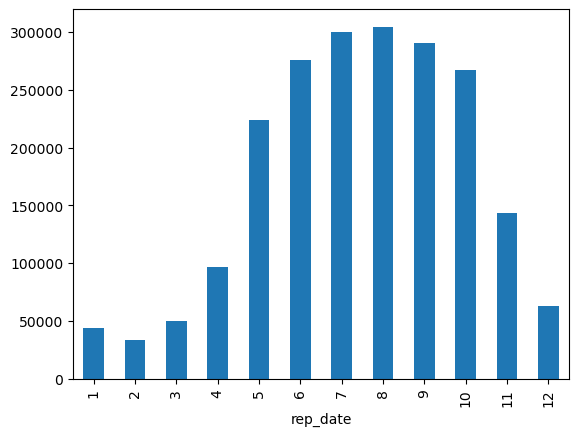

In [92]:
df_calc1['rep_date'].groupby(df_calc1['rep_date'].dt.month).count().plot(kind='bar')

In [89]:
df_calc1_dateOnly=pd.DataFrame(df_calc1['rep_date'])
df_calc1_dateOnly=pd.to_datetime(df_calc1['rep_date']).dt.date
df_calc1_dateOnly

0          2020-01-01
1          2020-01-01
3          2020-01-01
4          2020-01-01
6          2020-01-01
              ...    
3161901    2025-01-21
3161903    2025-01-21
3161907    2025-01-21
3161909    2025-01-21
3161911    2025-01-21
Name: rep_date, Length: 2090540, dtype: object

In [86]:
df_calc1_dateOnly.dt.month

AttributeError: Can only use .dt accessor with datetimelike values